In [14]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xgboost as xgb

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import pickle
import pandas as pd
import shap
import matplotlib.pyplot as plt
import os

In [5]:
#pip install shap

In [22]:


def plot_single_shap_explanation(model, X, index=0):
    """
    Generate a SHAP force plot for a single prediction.

    Parameters
    ----------
    model : trained tree-based model (e.g., XGBClassifier)
    X : pandas.DataFrame
        The feature matrix used for prediction.
    index : int
        Row index of the observation to explain.
    """

    # Create SHAP TreeExplainer
    explainer = shap.TreeExplainer(model)
    
    # Calculate SHAP values
    shap_values = explainer.shap_values(X)
    
    # Display the force plot for a single prediction
    shap.initjs()
    display(
        shap.force_plot(
            explainer.expected_value,
            shap_values[index, :],
            X.iloc[index, :],
            matplotlib=True
        )
    )

    # Optionally save as PNG
    plt.savefig(f"shap_single_explanation_{index}.png", bbox_inches='tight', dpi=300)
    plt.show()




def plot_single_shap_waterfall(model, X, index=0, max_display=10):
    """
    Display a clean SHAP waterfall plot for a single prediction.
    
    Args:
        model: Trained model.
        X (pd.DataFrame): Feature matrix.
        index (int): Row index to explain.
        max_display (int): Number of top features to show.
    """
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)

    shap.plots.waterfall(shap_values[index], max_display=max_display)


In [12]:
from pathlib import Path

def load_pickle_model(dir="outputs\\models", model_file="premature_model.pkl"):
    """
    Load a trained model saved as a pickle (.pkl) file.

    Args:
        dir (str): Relative directory path where the model is stored.
        model_file (str): Name of the pickle file to load.

    Returns:
        The loaded model object.
    """
    # Go one level up from current working directory
    base_dir = os.path.dirname(os.getcwd())  # e.g., "c:\\Users\\linoc\\OneDrive\\Encoder\\03_partos"
    model_dir = os.path.join(base_dir, dir)
    model_path = os.path.join(model_dir, model_file)

    # Check if file exists
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"❌ Model file not found at: {model_path}")

    # Load model
    with open(model_path, "rb") as f:
        model = pickle.load(f)

    print(f"✅ Model loaded successfully from: {model_path}")
    return model



# def load_features(data_path):
#     """
#     Load feature dataset (CSV) used for SHAP explanations.
#     """
#     X = pd.read_csv(data_path)
#     print(f"✅ Data loaded successfully — shape: {X.shape}")
#     return X


def plot_single_shap_explanation(model, X, index=0, save_dir="outputs/plots"):
    """
    Generate a SHAP force plot for a single prediction and save as PNG.
    """
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap.initjs()
    shap.force_plot(
        explainer.expected_value,
        shap_values[index, :],
        X.iloc[index, :],
        matplotlib=True
    )

    output_path = Path(save_dir) / f"shap_single_explanation_{index}.png"
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ SHAP explanation saved to: {output_path}")


# if __name__ == "__main__":
#     # Example usage (you can call this from notebook or CLI)
#     model = load_model("YOUR_MODEL_PATH.pkl")
#     X = load_features("YOUR_FEATURES_PATH.csv")
#     plot_single_shap_explanation(model, X, index=0)


In [15]:
# Load your trained premature propensity model
model = load_pickle_model(
    dir="outputs\\models\\",
    model_file="trained_model_4_20251022_141748.pkl"
)

model 

#plot_single_shap_explanation(model, X, index=3)

✅ Model loaded successfully from: c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\outputs\models\trained_model_4_20251022_141748.pkl


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=650, n_jobs=-1,
              num_parallel_tree=None, random_state=123, ...)

In [19]:
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos

data_train_path = os.path.join(base_dir,"data\\interim", "data_train.csv")
data_train = pd.read_csv(data_train_path, low_memory=False)
data_train_model = data_train[model.get_booster().feature_names]
data_train_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   REC94_S410B      18335 non-null  float64
 1   REC41_M44        18335 non-null  float64
 2   REC41_M14        18335 non-null  float64
 3   REC94_S411J      18335 non-null  float64
 4   REC94_QI422A_B   18335 non-null  float64
 5   RE516171_V631    18335 non-null  float64
 6   REC94_S411K      18335 non-null  float64
 7   REC94_S411I      18335 non-null  float64
 8   RE516171_V504    18335 non-null  float64
 9   REC41_M42C       18335 non-null  float64
 10  REC91_V228       18335 non-null  int64  
 11  REC41_M43        18335 non-null  float64
 12  REC41_M45        18335 non-null  float64
 13  CSALUD01_QS25AA  18335 non-null  float64
 14  REC91_V208       18335 non-null  float64
 15  CSALUD01_QS27    18335 non-null  float64
 16  REC91_V212       18335 non-null  float64
 17  REC41_M13   

In [26]:
probabilities = model.predict_proba(data_train_model)[:, 1]  # column 1 = positive class

# 2️⃣ Add new column to dataframe
data_train["SCORE_PROBABILITY"] = probabilities

# 3️⃣ Optional: round and display sample
data_train["SCORE_PROBABILITY"] = data_train["SCORE_PROBABILITY"].round(4)

# 4️⃣ Check result
data_train.head()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_V212,REC91_V228,REC91_V218,REC91_V208,REC91_V217,...,CSALUD01_QS25AA,CSALUD01_QS25BB,CSALUD01_QS406,CSALUD01_QS100,CSALUD01_QS107,CSALUD01_QS206,CSALUD01_QS25A,CSALUD01_QS25C5,CSALUD01_QS25C3,SCORE_PROBABILITY
0,325503101 2,1,7,1,1,0.44,0,0.285714,0.5,0.285714,...,0.108335,0.106971,0.093035,0.093748,0.098314,0.101018,0.094127,0.099599,0.099551,0.9309
1,325504701 2,1,9,0,0,0.36,0,0.285714,0.5,1.000000,...,0.107225,0.105892,0.127632,0.107224,0.100254,0.100517,0.094423,0.099562,0.099595,0.0167
2,325505001 1,1,9,0,0,0.24,0,0.285714,0.5,0.571429,...,0.056260,0.104496,0.092348,0.092712,0.097963,0.100438,0.095367,0.099462,0.099529,0.0168
3,325508901 2,1,9,0,0,0.40,0,0.285714,0.5,0.714286,...,0.106756,0.104496,0.130102,0.092712,0.097963,0.100438,0.095367,0.099462,0.099529,0.0136
4,325509701 2,1,9,0,0,0.40,0,0.285714,0.5,0.285714,...,0.106756,0.107466,0.092348,0.092712,0.097963,0.100438,0.095367,0.099462,0.099529,0.0130


In [28]:
data_train.sort_values(by="SCORE_PROBABILITY", ascending=False, inplace = True)
data_train.head()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_V212,REC91_V228,REC91_V218,REC91_V208,REC91_V217,...,CSALUD01_QS25AA,CSALUD01_QS25BB,CSALUD01_QS406,CSALUD01_QS100,CSALUD01_QS107,CSALUD01_QS206,CSALUD01_QS25A,CSALUD01_QS25C5,CSALUD01_QS25C3,SCORE_PROBABILITY
14765,589108001 2,1,7,1,1,0.88,1,0.142857,0.5,0.285714,...,0.108335,0.106971,0.093035,0.106758,0.102805,0.101018,0.120432,0.099599,0.099551,0.9524
1659,355907801 2,1,7,1,1,0.96,1,0.142857,0.5,0.285714,...,0.106648,0.095749,0.128592,0.108215,0.098164,0.101001,0.106310,0.099507,0.099548,0.9494
16453,618205601 2,1,7,1,1,0.92,1,0.142857,0.5,0.142857,...,0.107423,0.105769,0.093523,0.108143,0.097876,0.100891,0.095171,0.099514,0.099599,0.9490
9070,487716401 2,1,7,1,1,0.80,1,0.285714,0.5,0.285714,...,0.106648,0.107197,0.092667,0.092548,0.103657,0.101001,0.094100,0.099507,0.099548,0.9488
9609,497004301 2,1,7,1,1,0.32,1,0.142857,0.5,0.142857,...,0.080764,0.092301,0.092348,0.092712,0.097963,0.100438,0.095367,0.099462,0.099529,0.9487


In [29]:
data_train.tail()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_V212,REC91_V228,REC91_V218,REC91_V208,REC91_V217,...,CSALUD01_QS25AA,CSALUD01_QS25BB,CSALUD01_QS406,CSALUD01_QS100,CSALUD01_QS107,CSALUD01_QS206,CSALUD01_QS25A,CSALUD01_QS25C5,CSALUD01_QS25C3,SCORE_PROBABILITY
15312,598202601 1,1,9,0,0,0.24,0,0.285714,0.5,1.000000,...,0.018060,0.060242,0.092667,0.092548,0.098164,0.101001,0.094100,0.099507,0.099548,0.0068
59,326412801 1,1,9,0,0,0.28,0,1.000000,0.5,0.285714,...,0.028054,0.070630,0.130102,0.092712,0.097963,0.100438,0.095367,0.099462,0.099529,0.0068
15305,598107701 2,1,9,0,0,0.16,1,0.571429,0.5,0.714286,...,0.028533,0.067531,0.093523,0.092603,0.097876,0.083902,0.120292,0.099514,0.099599,0.0066
12288,544002601 2,1,9,0,0,0.20,1,0.428571,0.5,0.714286,...,0.023233,0.070630,0.093035,0.093748,0.098314,0.082611,0.120432,0.099599,0.099551,0.0063
6172,434611101 2,1,9,0,0,0.44,0,0.714286,0.5,1.000000,...,0.028054,0.070630,0.092348,0.108028,0.097963,0.100438,0.095367,0.099462,0.099529,0.0061


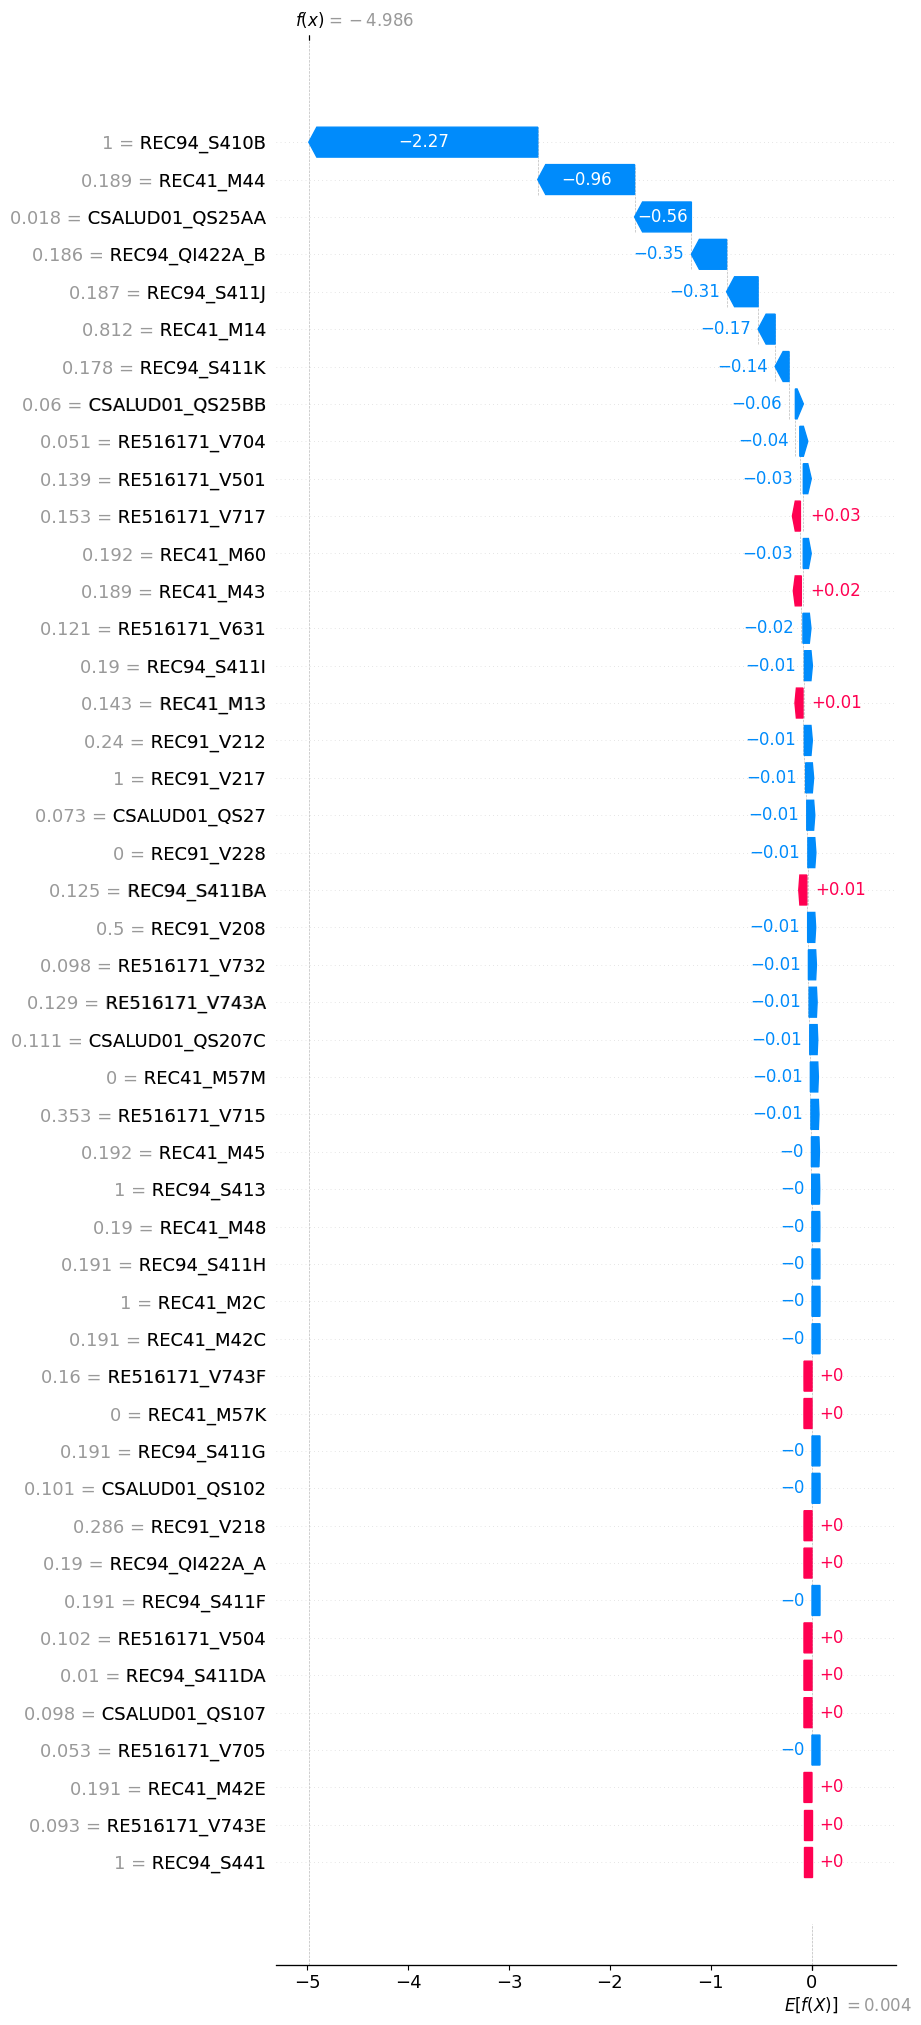

In [35]:
plot_single_shap_waterfall(model, data_train_model, index=15312, max_display=50)

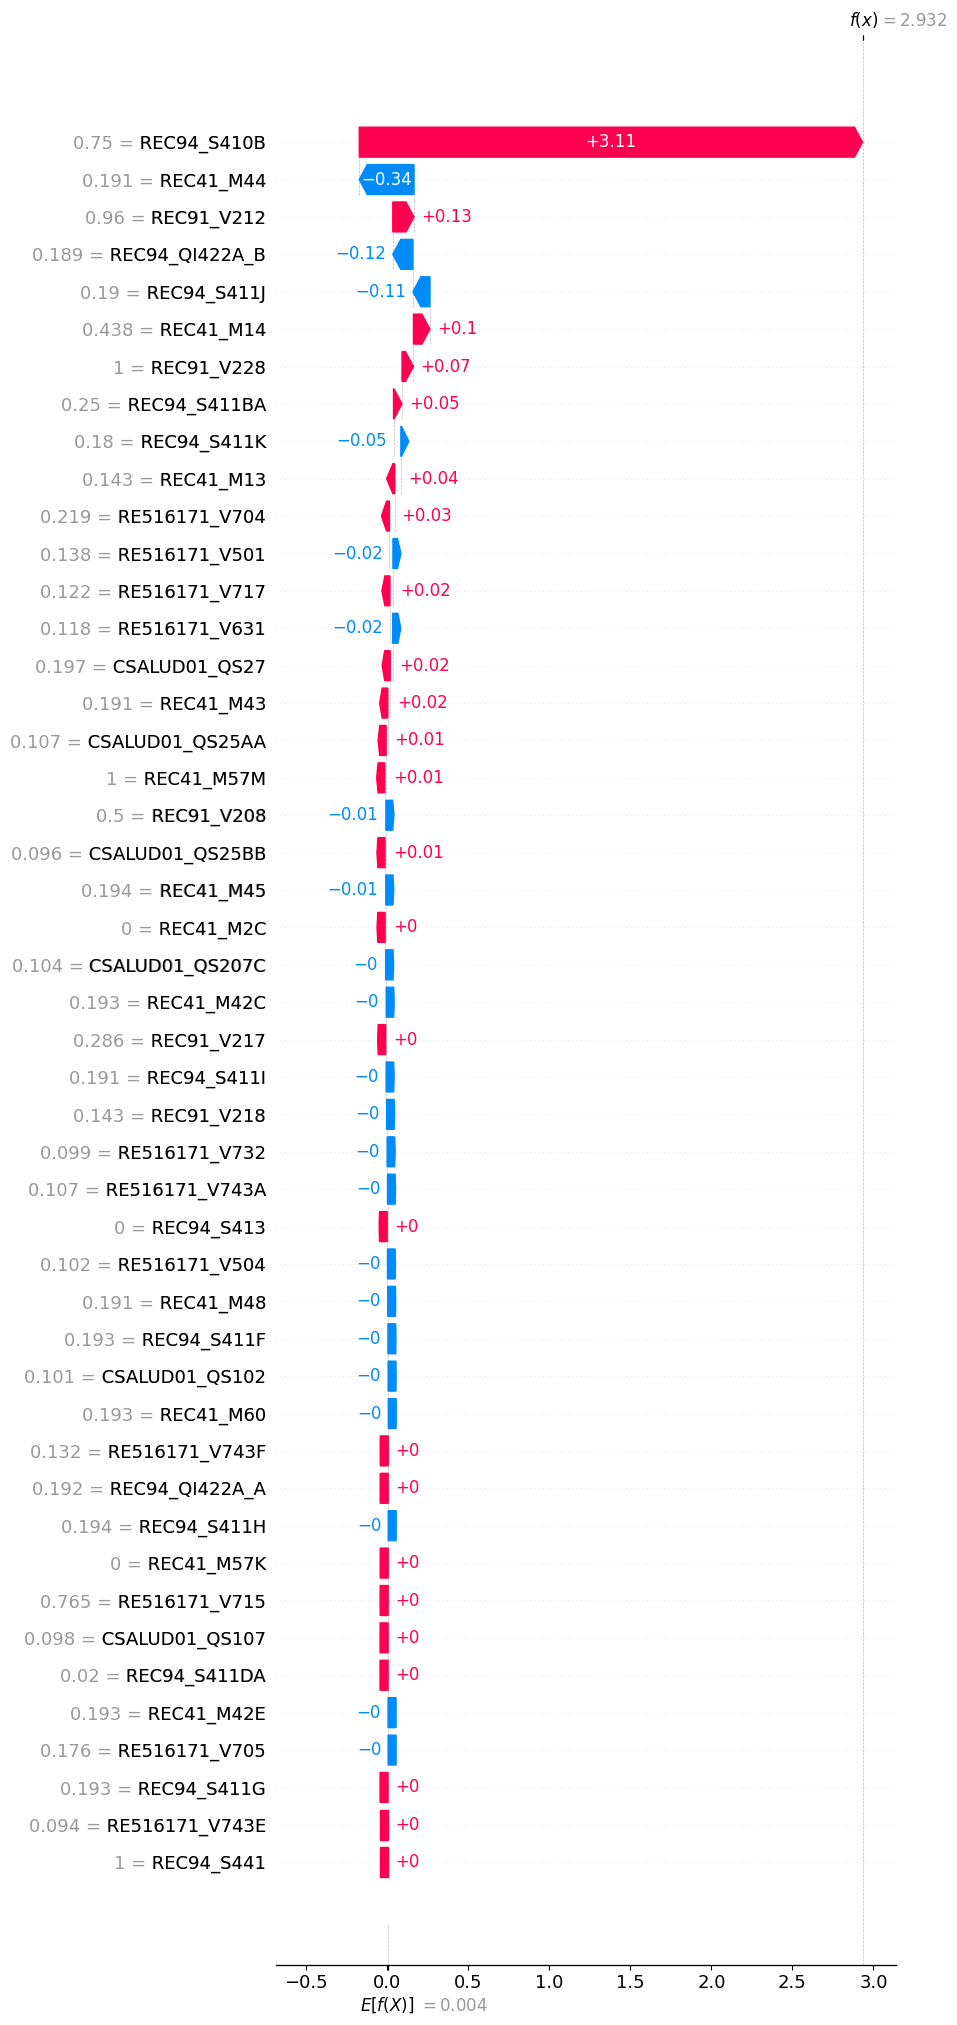

In [34]:
plot_single_shap_waterfall(model, data_train_model, index=1659, max_display=50)